In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [9]:
dar = pd.read_csv('data/snATAC_data/sig_dar_logfc_0.8_padj_0.05.csv')
dar

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,group,celltype
0,42.878727,-0.938135,0.231232,-4.057121,4.968145e-05,1.363999e-02,COH_2w,Amacrine cell
1,48.045714,-0.870610,0.159987,-5.441756,5.275789e-08,1.376838e-04,COH_2w,Amacrine cell
2,39.632849,-0.911861,0.183276,-4.975354,6.512864e-07,7.829488e-04,COH_2w,Amacrine cell
3,47.779315,-0.895316,0.217069,-4.124569,3.714297e-05,1.156944e-02,COH_2w,Amacrine cell
4,31.513661,-0.825228,0.185159,-4.456869,8.316526e-06,4.316129e-03,COH_2w,Amacrine cell
...,...,...,...,...,...,...,...,...
3443,42.777939,-1.015200,0.281109,-3.611415,3.045311e-04,1.132561e-02,COH_8w,Rod
3444,38.327980,-0.860991,0.227033,-3.792364,1.492202e-04,7.532576e-03,COH_8w,Rod
3445,33.129716,-0.849356,0.253962,-3.344426,8.245317e-04,1.921447e-02,COH_8w,Rod
3446,64.012157,0.981726,0.140107,7.006980,2.435172e-12,1.405459e-08,COH_8w,Rod


In [3]:
celltypes = ['Amacrine cell','Rod','Muller glia','Bipolar cell','Retinal ganglion cell','Cone','Horizontal cell']

In [4]:
celltypes

['Amacrine cell',
 'Rod',
 'Muller glia',
 'Bipolar cell',
 'Retinal ganglion cell',
 'Cone',
 'Horizontal cell']

In [10]:
deg = {
    '2w_up':[],
    '4w_up':[],
    '8w_up':[],
    '2w_down':[],
    '4w_down':[],
    '8w_down':[]
}
for celltype in celltypes:
    deg['2w_up'].append(len(dar[(dar["group"] == "COH_2w") & (dar["celltype"] == celltype) & (dar["log2FoldChange"] > 0)]))
    deg['4w_up'].append(len(dar[(dar["group"] == "COH_4w") & (dar["celltype"] == celltype) & (dar["log2FoldChange"] > 0)]))
    deg['8w_up'].append(len(dar[(dar["group"] == "COH_8w") & (dar["celltype"] == celltype) & (dar["log2FoldChange"] > 0)]))
    deg['2w_down'].append(len(dar[(dar["group"] == "COH_2w") & (dar["celltype"] == celltype) & (dar["log2FoldChange"] < 0)]))
    deg['4w_down'].append(len(dar[(dar["group"] == "COH_4w") & (dar["celltype"] == celltype) & (dar["log2FoldChange"] < 0)]))
    deg['8w_down'].append(len(dar[(dar["group"] == "COH_8w") & (dar["celltype"] == celltype) & (dar["log2FoldChange"] < 0)]))

In [11]:
deg = pd.DataFrame(deg)

In [12]:
deg['celltype'] = celltypes
deg.set_index('celltype',inplace=True)
deg

,2w_up,4w_up,8w_up,2w_down,4w_down,8w_down
celltype,,,,,,
Amacrine cell,0,0,1,101,0,1
Rod,196,12,2,5,0,57
Muller glia,90,14,31,37,35,494
Bipolar cell,0,0,0,36,2,0
Retinal ganglion cell,141,33,15,1313,457,362
Cone,0,1,2,0,1,4
Horizontal cell,0,0,3,0,0,2


In [13]:
cmap1 = sns.color_palette("Greens", as_cmap=True) 
cmap2 = sns.color_palette("Purples", as_cmap=True)

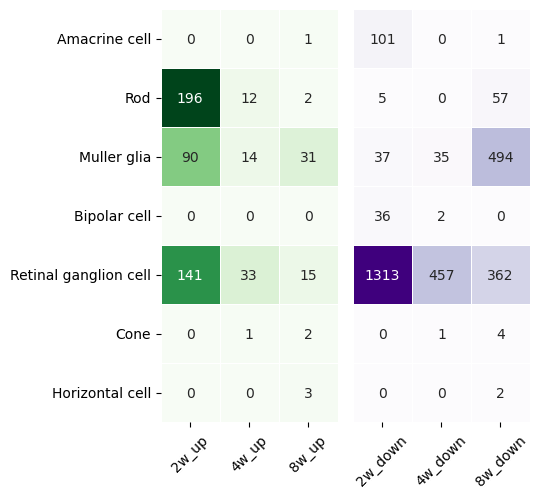

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 6))

sns.heatmap(deg.iloc[:, :3], cmap=cmap1, annot=True, fmt='d', cbar_kws={'label': 'DEG Count'}, 
            linewidths=0.5, annot_kws={'size': 10}, cbar=False, square=True, ax=axes[0])
sns.heatmap(deg.iloc[:, 3:], cmap=cmap2, annot=True, fmt='d', cbar_kws={'label': 'DEG Count'}, 
            linewidths=0.5, annot_kws={'size': 10}, cbar=False, square=True, ax=axes[1])

axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])
axes[1].tick_params(axis='y', length=0)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()